# T15: Machine Learning with scikit-learn
CHE-226, Programming and Data Science

**Learning objective:** explain what it means for a model to learn from data, train and test a classifier and a regressor with scikit-learn's fit/predict pattern, evaluate them honestly with test sets, confusion matrices, and cross-validation, and question a model's accuracy before trusting it with a safety decision.

**Teaches:** (KA-01)

*Spans two class meetings; see the class break marker partway through.*

## Agenda: This Class
1. What is machine learning?
2. The scikit-learn workflow
3. k-nearest neighbors
4. A real dataset: handwritten digits
5. Training and test sets

# 1. What Is Machine Learning?

### Concept
A model maps inputs to an output. Physics sometimes gives that map as an equation; machine learning estimates it from examples when no equation is available.

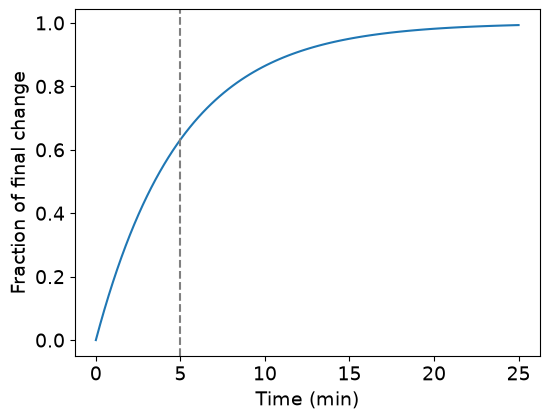

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size": 14})

tau = 5.0                                  # time constant, min
t = np.linspace(0, 25, 100)                # min after a step change
y = 1 - np.exp(-t / tau)                   # first-order response
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(t, y); ax.axvline(tau, ls="--", color="gray")
ax.set_xlabel("Time (min)"); ax.set_ylabel("Fraction of final change")
plt.show()

Detailed notes: Supervised learning learns from labeled examples, inputs paired with known outputs: classification predicts a category (faulty or healthy, which digit), regression predicts a number (a cost, a yield). Unsupervised learning finds structure without labels, for example k-means clustering grouping operating data into regimes. The first-order response is a system whose map from input to output is known exactly: after a step change, the output covers 1 - exp(-t/tau) of the way to its new value. Machine learning is for the many maps no one has written down, such as product quality from dozens of sensor readings. Stress that machine learning complements physics; it does not replace it.

**Sneak Peek: T-10.01.03 First and Second Order Response (KA-10)**
A first-order system responds to a step change as y = 1 - exp(-t/tau). You will study dynamic response fully in process dynamics and control.

### Activity: predict then run
What fraction of the final change has the system covered at t = tau, and at t = 3 tau?

In [ ]:
print(round(1 - np.exp(-1), 3), round(1 - np.exp(-3), 3))

Answer: 0.632 and 0.95. One time constant gives 63.2 percent of the response; three give 95 percent, the usual engineering rule for when a first-order system has effectively settled.

# 2. The scikit-learn Workflow

### Concept
Every scikit-learn model follows the same steps: create an estimator, `fit` it on labeled data, then `predict` for new inputs. `score` reports how well it does.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# pump data: [vibration mm/s, bearing temperature C] -> condition
X = [[2.0, 55], [2.5, 60], [3.0, 58], [7.5, 80], [8.0, 85], [6.5, 78]]
y = ["ok", "ok", "ok", "fault", "fault", "fault"]

knn = KNeighborsClassifier(n_neighbors=3)    # 1. create
knn.fit(X, y)                                # 2. learn from examples
print(knn.predict([[2.8, 62], [7.0, 82]]))   # 3. predict new pumps
print(knn.score(X, y))                       # 4. accuracy on X

Detailed notes: scikit-learn wraps each algorithm in an estimator object with the same interface, so switching from k-nearest neighbors to a decision tree changes one line. Sensible default settings mean a first model needs very little code, which is powerful but also means the engineer must still check what the model is doing. X is 2D (samples by features, as in T10) and y holds one label per sample. Scoring on the same data used for fitting, as in the last line, is optimistic; Section 5 fixes that. The pump numbers are invented for illustration.

### Activity: cold call
In one sentence each: what does `fit` do, and what does `predict` do? Which one needs the labels `y`?

Answer: fit learns from examples whose answers are known, so it needs X and y; predict applies what was learned to new inputs, so it needs only X. For k-nearest neighbors, fit mostly just stores the examples, which leads into the next section.

# 3. k-Nearest Neighbors

### Concept
k-NN classifies a new sample by finding the k training samples closest to it and taking a majority vote of their labels. k is a hyperparameter: you choose it, the model does not learn it.

In [ ]:
X1 = [[340], [345], [350], [358], [362], [365]]   # reactor T, K
y1 = ["normal", "normal", "normal", "high", "high", "high"]

for k in [1, 3, 5]:
    model = KNeighborsClassifier(n_neighbors=k).fit(X1, y1)
    print(k, model.predict([[352]]))

Detailed notes: k-NN is lazy learning: it stores the training data and does all the work at prediction time, measuring the distance (Euclidean by default) from the new point to every stored point. A small k follows the training data closely and is sensitive to noise; a large k smooths the decision boundary but can blur real distinctions. An odd k avoids ties in two-class problems. Because distance drives everything, features on very different scales (mm/s versus degrees) should be standardized first, or the larger one dominates. Parameters learned from data (like a regression slope) are different from hyperparameters set beforehand (like k); tuning k comes in Section 9.

### Activity: trace the variable
Training temperatures are 340, 345, 350 (normal) and 358, 362, 365 (high). By hand, with k = 3, classify a reading of 355 K.

In [ ]:
m3 = KNeighborsClassifier(n_neighbors=3).fit(X1, y1)
print(m3.predict([[355]]), m3.kneighbors([[355]])[1])

Answer: high. The distances from 355 are 5 (350), 3 (358), 7 (362), 10 (345), 10 (365), 15 (340); the three nearest are 358, 350, and 362, which vote high, normal, high. The printed indices [3, 2, 4] identify those same three neighbors.

# 4. A Real Dataset: Handwritten Digits

### Concept
scikit-learn bundles small datasets for practice. The digits dataset holds 1797 images of handwritten 0-9, each 8 by 8 pixels, flattened into 64 numbers per sample.

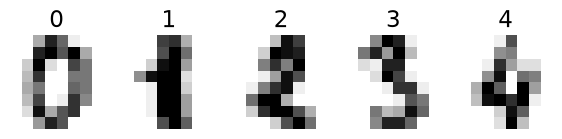

In [ ]:
from sklearn.datasets import load_digits
digits = load_digits()

fig, axes = plt.subplots(1, 5, figsize=(7, 2))
for ax, img, label in zip(axes, digits.images, digits.target):
    ax.imshow(img, cmap="gray_r")            # 8 x 8 pixel image
    ax.set_title(label); ax.axis("off")
plt.show()
print(digits.data[0][:8])                    # first row of pixels

Detailed notes: This is a classic benchmark for classification (it comes from the UCI machine learning repository, originally postal code recognition). Each image is 8 x 8 pixels with intensities 0 to 16. Models in scikit-learn need one row of numbers per sample, so digits.data holds each image flattened to 64 features, while digits.images keeps the 2D form for plotting; the flattening is the reshape from T7. digits.target holds the true labels. Real engineering datasets rarely arrive this clean: most of the effort in a data science study goes into collecting, cleaning, and preparing data (T8 and T9) before any model is trained.

### Activity: predict then run
Before running, give the shape of each array.

In [ ]:
print(digits.data.shape, digits.images.shape, digits.target.shape)

Answer: (1797, 64) (1797, 8, 8) (1797,). 1797 samples throughout; 64 = 8 x 8 features per flattened image; one label per sample.

# 5. Training and Test Sets

### Concept
A model must be judged on data it has not seen. `train_test_split` holds back part of the data for testing; `random_state` makes the split reproducible.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

rng = np.random.default_rng(3)                 # 40 synthetic plants
cap = rng.uniform(10, 500, 40)                 # capacity, kt/yr
cost = 50 * (cap / 100) ** 0.6 * rng.lognormal(0, 0.1, 40)  # M$
X = np.log(cap).reshape(-1, 1); y = np.log(cost)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25,
                                          random_state=11)
reg = LinearRegression().fit(X_tr, y_tr)
print(f"exponent {reg.coef_[0]:.2f}, "
      f"test R^2 {reg.score(X_te, y_te):.3f}")

Detailed notes: Scoring a model on its own training data rewards memorization; a held-out test set estimates how it will do on new cases. The split shuffles first, so a random_state makes results reproducible, as a seed did in T4. Here the synthetic plants follow the six-tenths rule, cost proportional to capacity to the power 0.6, with scatter. Taking logs turns that power law into a straight line whose slope is the exponent, so linear regression recovers roughly 0.6 from the data. The same fit/predict/score calls work for regression and classification alike.

**Sneak Peek: T-11.04.01 Capital Cost Estimation (KA-11)**
The six-tenths rule, cost proportional to capacity^0.6, scales plant cost with size. A regression on past plants estimates the exponent. You will study cost estimation fully in plant design and economics.

### Activity: predict then run
40 samples with `test_size=0.25`. How many land in each set?

In [ ]:
print(len(X_tr), len(X_te))

Answer: 30 and 10. test_size=0.25 holds back a quarter. The default, when test_size is not given, is also 0.25.

## Class Break
Covered so far: what machine learning is, the fit/predict workflow, k-NN, the digits dataset, train and test sets.

## Agenda: Next Class
6. Training a digit classifier
7. Confusion matrices, precision, and recall
8. K-fold cross-validation
9. Comparing models and tuning hyperparameters
10. Responsible AI: when 98 percent is not good enough

# 6. Training a Digit Classifier

### Concept
Split the digits, fit k-NN on the training images, predict the test images, and compare predictions with the true labels.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    digits.data, digits.target, random_state=11)

knn = KNeighborsClassifier()                 # default k = 5
knn.fit(X_train, y_train)
predicted = knn.predict(X_test)
print(predicted[:20]); print(y_test[:20])
wrong = [(p, e) for p, e in zip(predicted, y_test) if p != e]
print(f"{len(wrong)} wrong, accuracy {knn.score(X_test, y_test):.2%}")

Detailed notes: The full workflow in six lines: split, create, fit, predict, compare, score. The default split holds back 25 percent, 450 test images here. The list comprehension from T5 picks out the (predicted, expected) pairs that disagree, which is the first thing to look at: are the errors random, or does the model confuse particular pairs such as 3 and 8? k-NN does remarkably well on this dataset with no tuning. Accuracy is the fraction correct, which is a good summary only when the classes are roughly balanced, as the ten digits are here.

### Activity: cold call
The model scores about 98 percent. What accuracy would a useless model get by always guessing the same digit? Why does that comparison matter?

Answer: about 10 percent, since the ten digits appear roughly equally often. An accuracy is only impressive compared with a baseline; Section 10 shows a case where the trivial baseline is 98 percent.

# 7. Confusion Matrices, Precision, and Recall

### Concept
A confusion matrix counts each (true, predicted) pair. For a yes/no question, precision asks how many alarms were real; recall asks how many real cases were caught.

In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, \
    recall_score
rng = np.random.default_rng(5)         # 300 synthetic release scenarios
rate = rng.uniform(0, 10, 300)         # release rate, kg/s
wind = rng.uniform(1, 10, 300)         # wind speed, m/s
Xh = np.column_stack([rate, wind])
yh = (rate / wind + rng.normal(0, 0.3, 300) > 1.5).astype(int)
Xh_tr, Xh_te, yh_tr, yh_te = train_test_split(Xh, yh, random_state=2)
pred_h = KNeighborsClassifier().fit(Xh_tr, yh_tr).predict(Xh_te)
print(confusion_matrix(yh_te, pred_h))  # rows true, cols predicted

Detailed notes: Rows are the true class and columns the predicted class, so the diagonal holds correct predictions and everything else is a mistake; for digits it is 10 x 10 and shows exactly which digits get confused. For a two-class problem the off-diagonal cells are false positives (a false alarm) and false negatives (a missed case). Precision = TP / (TP + FP); recall = TP / (TP + FN). classification_report prints both, plus their combination F1, for every class. The toy scenario labels a release hazardous (1) when the release rate is high relative to the wind that dilutes it; real consequence models are far richer, but the evaluation question is the same.

**Sneak Peek: T-13.02.01 Consequence Modelling (KA-13)**
Consequence models estimate how far a toxic or flammable release spreads. Classifying a scenario as hazardous or not is a yes/no prediction, judged by its misses. You will study it fully in process safety.

### Activity: think-pair-share
For this hazard model, which mistake is worse: a false alarm or a missed hazard? So should we care more about precision or recall? Discuss, then we will check the numbers.

In [ ]:
print(f"precision {precision_score(yh_te, pred_h):.2f}, "
      f"recall {recall_score(yh_te, pred_h):.2f}")

Answer: a missed hazard (false negative) is worse: people are exposed with no warning, while a false alarm costs an unnecessary response. So recall matters most here, even at some cost in precision. Defensible counterpoint: too many false alarms train operators to ignore them, so precision cannot be ignored either. The run gives precision 0.79 and recall 0.90: 2 of 21 true hazards were missed, and 5 of 24 alarms were false.

# 8. K-Fold Cross-Validation

### Concept
One train/test split can be lucky or unlucky. K-fold cross-validation splits the data into k folds and tests on each fold in turn, training on the rest, giving k scores.

In [ ]:
from sklearn.model_selection import KFold, cross_val_score

kfold = KFold(n_splits=10, shuffle=True, random_state=11)
scores = cross_val_score(KNeighborsClassifier(), digits.data,
                         digits.target, cv=kfold)
print(scores.round(3))
print(f"mean {scores.mean():.2%}, std {scores.std():.2%}")

Detailed notes: With 10 folds, every sample is used for testing exactly once and for training nine times, and the model is refit from scratch for each fold. The mean of the scores is a more reliable estimate of performance than one split; the standard deviation shows how much that estimate depends on which samples land in the test set. The cost is k times the training work, trivial here but significant for large models. shuffle=True with a random_state avoids folds that happen to follow some ordering in the file, a real risk with process data logged in time order.

### Activity: predict then run
How many scores will this return? Roughly what will their mean be?

In [ ]:
print(len(cross_val_score(KNeighborsClassifier(), digits.data,
                          digits.target, cv=5)))

Answer: 5, one per fold (cv=5 means 5 folds); the mean is again around 96 to 99 percent. Without shuffle, the folds follow file order, so the scores may vary more.

# 9. Comparing Models and Tuning Hyperparameters

### Concept
Cross-validation gives a fair way to compare different estimators and to choose a hyperparameter such as k: try each option and keep the best mean score.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

models = {"k-NN": KNeighborsClassifier(),
          "DecisionTree": DecisionTreeClassifier(random_state=0),
          "GaussianNB": GaussianNB()}
for name, model in models.items():
    s = cross_val_score(model, digits.data, digits.target, cv=kfold)
    print(f"{name:>12}: mean {s.mean():.2%}, std {s.std():.2%}")

Detailed notes: Because every estimator shares the same interface, a dictionary of models (T6) and one loop compare them fairly on identical folds. There is no universally best algorithm; the best one depends on the data, which is why trying several is standard practice. The same loop tunes a hyperparameter: vary k for k-NN and keep the value with the best cross-validated score. GridSearchCV automates this search. Accuracy is not the only criterion: interpretability (a decision tree can be read), training and prediction time, and behavior outside the training range all matter for an engineering deployment.

### Activity: cold call
Why tune k with cross-validation on the training data, instead of just picking the k that scores best on the test set?

In [ ]:
for k in [1, 3, 5, 7]:
    s = cross_val_score(KNeighborsClassifier(n_neighbors=k),
                        X_train, y_train, cv=kfold)
    print(k, f"{s.mean():.2%}")

Answer: choosing k by test score leaks the test set into the design, so the test score is no longer an honest estimate of performance on new data; the model has been tuned to that particular test set. Tune with cross-validation on training data, then use the test set once, at the end.

# 10. Responsible AI: When 98 Percent Is Not Good Enough

### Concept
Accuracy can hide failure. If real failures are rare, a model that never predicts one scores highly and is useless. Engineers stay accountable for decisions made with a model.

In [ ]:
from sklearn.metrics import accuracy_score
y_true = np.zeros(1000, dtype=int)
y_true[:20] = 1                                  # 20 failures: 2%
y_lazy = np.zeros(1000, dtype=int)               # always "no failure"

print(f"accuracy {accuracy_score(y_true, y_lazy):.1%}")
print(f"recall {recall_score(y_true, y_lazy):.1%}")

Detailed notes: With 2 percent failures, predicting no failure every time is right 98 percent of the time and catches none of the failures: accuracy 98 percent, recall 0. Rare events are exactly the ones that matter in safety, reliability, and quality, so class imbalance is the normal case in process engineering, not an edge case. Beyond metrics, responsible use asks what data the model was trained on (only normal operation? a different plant?), whether it is used outside that range, whether its decisions can be explained and audited, and who answers for its failures. Professional codes of conduct put the safety, health, and welfare of the public first, and do not transfer that duty to software.

**Sneak Peek: T-14.01.02 Ethical Decision Making (KA-14)**
Engineering ethics asks who bears the risk of a decision and who answers for it. A machine learning model changes the tools, not the responsibility. You will study professional ethics fully in a later course.

### Activity: think-pair-share
A vendor offers a model, 98 percent accurate, that decides when a pressure vessel can skip its manual inspection. What would you ask before agreeing, and who is accountable if it misses a failure?

Answer: good questions: accuracy on what data, and what is the recall on real failures; was it trained on vessels, service conditions, and failure modes like ours; how does it behave outside that range; can its decisions be explained and audited; what human check remains. On accountability: the engineers and the organization that choose to rely on it remain responsible; the model cannot be. Push pairs past 'test it more' toward what evidence would actually be convincing.

## Recap and Lab Practice
- Machine learning estimates an input-output map from data: classification predicts categories, regression predicts numbers.
- Every scikit-learn estimator follows create, fit, predict, score. Judge a model on held-out data, and use cross-validation to compare models and tune hyperparameters.
- Look beyond accuracy: confusion matrices, precision, and recall expose what a model misses, and the engineer stays accountable.

Lab practice: train and cross-validate a classifier on a small plant dataset, report its confusion matrix and recall, and write a short paragraph on whether it is fit for use; ask if you want them turned into a lab worksheet.

Next: mini project workshop.